## Conditional Diffusion (improved)

This notebook extends the baseline conditional diffusion setup with techniques common in modern training and sampling:

1. **EMA** — exponential moving average of weights for more stable sampling.
2. **Classifier-free guidance (CFG)** — random label dropout during training; at inference, blend conditional and unconditional noise predictions.
3. **Cosine noise schedule** — beta schedule derived from a cosine cumulative alpha schedule (Nichol & Dhariwal) instead of linear betas.
4. **SNR-weighted loss (optional)** — **min-SNR-gamma** weighting is available; this notebook defaults to **uniform** timestep weights so a small U-Net still learns low-noise timesteps well (better DDIM tails).
5. **DDIM** — faster sampling with a shorter timestep schedule (a full DDPM loop is also available in `ImprovedDiffusion.sample_ddpm` for debugging).

Models are saved under `models/`. After **each epoch**, previews use **online weights** + **DDIM** + **CFG=1** (EMA is still saved for the Generation section). Upsampling uses **nearest resize + conv** instead of transposed convolution to avoid checkerboard striping.


In [1]:
import os
import copy
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from torchvision.datasets import FashionMNIST
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from torchvision.utils import make_grid
from einops import rearrange
from torch import einsum

device = "cuda" if torch.cuda.is_available() else "cpu"
MODELS_DIR = "models"
ASSETS_DIR = "assets"
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(ASSETS_DIR, exist_ok=True)


## Fashion-MNIST dataset preprocessing


100%|██████████| 26.4M/26.4M [00:50<00:00, 527kB/s] 
100%|██████████| 29.5k/29.5k [00:00<00:00, 398kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.69MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 9.69MB/s]


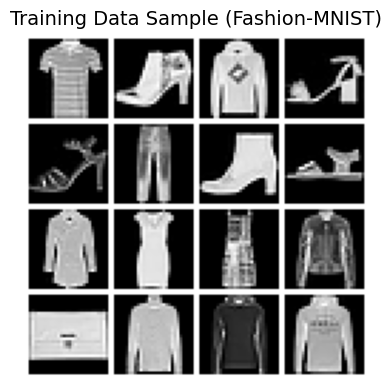

In [2]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

transform = transforms.Compose([
    transforms.Resize(28),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

train_dataset = FashionMNIST(root="./data", train=True, transform=transform, download=True)
test_dataset = FashionMNIST(root="./data", train=False, transform=transform, download=True)

dataloader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2)
testloader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

images, labels = next(iter(dataloader))
grid = make_grid(images[:16], nrow=4, normalize=False, pad_value=1)
plt.figure(figsize=(10, 4))
plt.imshow(grid.permute(1, 2, 0).cpu().numpy() * 0.5 + 0.5, cmap='gray')
plt.title("Training Data Sample (Fashion-MNIST)", fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()


## Diffusion process

`ImprovedDiffusion` builds a **cosine** alpha-bar schedule, precomputes **SNR** and **min-SNR-gamma** loss weights, and implements **DDIM** sampling. Timesteps are integers `t in {0, ..., T-1}` where **larger t means more noise** (Ho et al. convention).

**CFG** at sample time uses the learned null-class embedding (index `null_label`) with guidance scale `w >= 1`: `eps <- eps_u + w * (eps_c - eps_u)`.


In [3]:
def cosine_beta_schedule(timesteps, s=0.008):
    steps = timesteps + 1
    x = torch.linspace(0, timesteps, steps)
    alphas_cumprod = torch.cos(((x / timesteps) + s) / (1 + s) * math.pi * 0.5) ** 2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1.0 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    return torch.clip(betas, 1e-5, 0.999)


class ImprovedDiffusion:
    def __init__(self, num_timesteps, img_shape, device, min_snr_gamma=5.0, uniform_loss_weights=False):
        self.num_timesteps = num_timesteps
        self.img_shape = img_shape
        self.device = device
        self.min_snr_gamma = min_snr_gamma
        self.uniform_loss_weights = uniform_loss_weights

        betas = cosine_beta_schedule(num_timesteps)
        self.betas = betas.to(device)
        self.alphas = 1.0 - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
        self.alphas_cumprod_prev = F.pad(self.alphas_cumprod[:-1], (1, 0), value=1.0)

        ab = self.alphas_cumprod.clamp(min=1e-9)
        snr = ab / (1.0 - ab)
        self.snr = snr
        if uniform_loss_weights:
            # Min-SNR reweighting down-weights low-noise timesteps; on a small U-Net that can
            # underfit the tail of the denoising trajectory and cause blown-out DDIM samples.
            self.loss_weight = torch.ones(num_timesteps, device=device)
        else:
            clip = torch.full_like(snr, min_snr_gamma)
            self.loss_weight = torch.minimum(snr, clip) / snr.clamp(min=1e-9)

        self.posterior_variance = (
            self.betas * (1.0 - self.alphas_cumprod_prev) / (1.0 - self.alphas_cumprod).clamp(min=1e-9)
        )

    def sample_timesteps(self, n):
        return torch.randint(0, self.num_timesteps, (n,), device=self.device, dtype=torch.long)

    def noise_images(self, x0, t):
        ab = self.alphas_cumprod[t][:, None, None, None]
        noise = torch.randn_like(x0)
        xt = ab.sqrt() * x0 + (1.0 - ab).sqrt() * noise
        return xt, noise

    def predict_x0_from_eps(self, x, t, eps):
        ab = self.alphas_cumprod[t][:, None, None, None]
        return (x - (1.0 - ab).sqrt() * eps) / ab.sqrt().clamp(min=1e-8)

    def _predict_eps_cfg(self, model, x, t, labels, guidance_scale, null_label):
        if guidance_scale == 1.0:
            return model(x, t, labels)
        uncond = torch.full_like(labels, null_label)
        eps_c = model(x, t, labels)
        eps_u = model(x, t, uncond)
        return eps_u + guidance_scale * (eps_c - eps_u)

    @torch.no_grad()
    def sample_ddim(self, model, n, labels, steps=100, guidance_scale=2.0, null_label=10, eta=0.0, x_start=None):
        model.eval()
        if x_start is not None:
            x = x_start.to(self.device)
        else:
            x = torch.randn(n, *self.img_shape, device=self.device)
        ts = torch.linspace(0, self.num_timesteps - 1, steps, device=self.device).long()
        ts = torch.unique(ts).sort(descending=True).values
        ts_next = torch.cat([ts[1:], torch.tensor([-1], device=self.device)])

        for t_now, t_next in zip(ts.tolist(), ts_next.tolist()):
            t_b = torch.full((n,), t_now, device=self.device, dtype=torch.long)
            ab = self.alphas_cumprod[t_now]
            ab_next = self.alphas_cumprod[t_next] if t_next >= 0 else torch.ones((), device=self.device)

            eps = self._predict_eps_cfg(model, x, t_b, labels, guidance_scale, null_label)
            pred_x0 = self.predict_x0_from_eps(x, t_b, eps).clamp(-1, 1)

            if t_next < 0:
                x = pred_x0
                break

            sigma = (
                eta
                * (
                    (1.0 - ab_next) / (1.0 - ab).clamp(min=1e-9)
                    * (1.0 - ab / ab_next.clamp(min=1e-9))
                ).sqrt()
            )
            c1 = ab_next.sqrt()
            c2 = ((1.0 - ab_next) - sigma ** 2).clamp(min=0).sqrt()
            noise = torch.randn_like(x) if eta > 0 else 0.0
            x = c1 * pred_x0 + c2 * eps + sigma * noise

        model.train()
        x = (x.clamp(-1, 1) + 1) / 2
        return (x * 255).type(torch.uint8)

    @torch.no_grad()
    def sample_ddpm(self, model, n, labels, guidance_scale=1.0, null_label=10):
        model.eval()
        x = torch.randn(n, *self.img_shape, device=self.device)
        for t_now in tqdm(reversed(range(self.num_timesteps)), desc="DDPM", leave=False):
            t_b = torch.full((n,), t_now, device=self.device, dtype=torch.long)
            eps = self._predict_eps_cfg(model, x, t_b, labels, guidance_scale, null_label)
            beta = self.betas[t_b][:, None, None, None]
            ab = self.alphas_cumprod[t_b][:, None, None, None]
            ab_prev = self.alphas_cumprod_prev[t_b][:, None, None, None]
            alpha = self.alphas[t_b][:, None, None, None]

            pred_x0 = self.predict_x0_from_eps(x, t_b, eps).clamp(-1, 1)
            coef1 = beta * ab_prev.sqrt() / (1.0 - ab).clamp(min=1e-8)
            coef2 = (1.0 - ab_prev) * alpha.sqrt() / (1.0 - ab).clamp(min=1e-8)
            mean = coef1 * pred_x0 + coef2 * x

            if t_now > 0:
                noise = torch.randn_like(x)
                var = self.posterior_variance[t_b][:, None, None, None]
                x = (mean + var.sqrt() * noise).clamp(-1, 1)
            else:
                x = mean.clamp(-1, 1)
        model.train()
        x = (x.clamp(-1, 1) + 1) / 2
        return (x * 255).type(torch.uint8)


## Helper classes

Residual connections, sinusoidal time embeddings, linear and full attention, and conv blocks (aligned with the baseline notebook).


In [4]:
import torch.nn.functional as F

class Residual(nn.Module):
    def __init__(self, fn):
        super().__init__()
        self.fn = fn

    def forward(self, x, *args, **kwargs):
        return self.fn(x, *args, **kwargs) + x


class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, x):
        device = x.device
        half_dim = self.dim // 2
        emb = math.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=device) * -emb)
        emb = x[:, None] * emb[None, :]
        emb = torch.cat((emb.sin(), emb.cos()), dim=-1)
        return emb


class Upsample(nn.Module):
    """Nearest resize + conv avoids ConvTranspose2d checkerboard / vertical striping."""

    def __init__(self, dim):
        super().__init__()
        self.conv = nn.Conv2d(dim, dim, 3, padding=1)

    def forward(self, x):
        x = F.interpolate(x, scale_factor=2.0, mode="nearest")
        return self.conv(x)


def Downsample(dim):
    return nn.Conv2d(dim, dim, 4, 2, 1)


class LayerNorm(nn.Module):
    def __init__(self, dim, eps=1e-5):
        super().__init__()
        self.eps = eps
        self.g = nn.Parameter(torch.ones(1, dim, 1, 1))
        self.b = nn.Parameter(torch.zeros(1, dim, 1, 1))

    def forward(self, x):
        var = torch.var(x, dim=1, unbiased=False, keepdim=True)
        mean = torch.mean(x, dim=1, keepdim=True)
        return (x - mean) / (var + self.eps).sqrt() * self.g + self.b


class PreNorm(nn.Module):
    def __init__(self, dim, fn):
        super().__init__()
        self.fn = fn
        self.norm = LayerNorm(dim)

    def forward(self, x):
        x = self.norm(x)
        return self.fn(x)


class ConvBlock(nn.Sequential):
    def __init__(self, in_channel, out_channel, kern_size, padd, groups, downsample=True, use_act=True):
        super().__init__()
        self.add_module(
            "conv",
            nn.Conv2d(
                in_channel,
                out_channel,
                kern_size,
                stride=2 if downsample else 1,
                padding=padd,
                groups=groups,
            ),
        )
        self.add_module("norm", nn.GroupNorm(groups, out_channel))
        self.add_module("act", nn.SiLU() if use_act else nn.Identity())


class ResnetBlock(nn.Module):
    def __init__(self, in_channels, out_channels, *, time_emb_dim=None, groups=8, downsample=False):
        super().__init__()
        self.mlp = (
            nn.Sequential(nn.SiLU(), nn.Linear(time_emb_dim, out_channels))
            if time_emb_dim is not None
            else None
        )

        self.block1 = ConvBlock(in_channels, out_channels, 3, 1, groups, downsample=downsample)
        self.block2 = ConvBlock(out_channels, out_channels, 3, 1, groups, downsample=False, use_act=False)

        if in_channels != out_channels or downsample:
            self.res_conv = nn.Conv2d(
                in_channels, out_channels, kernel_size=1, stride=2 if downsample else 1
            )
        else:
            self.res_conv = nn.Identity()
        self.act = nn.SiLU()

    def forward(self, x, time_emb=None):
        res = self.res_conv(x)

        h = self.block1(x)
        if self.mlp is not None and time_emb is not None:
            time_emb = self.mlp(time_emb)
            h = h + time_emb[:, :, None, None]
        h = self.act(h)
        h = self.block2(h)

        return h + res


class Attention(nn.Module):
    def __init__(self, dim, heads=4, dim_head=32):
        super().__init__()
        self.scale = dim_head**-0.5
        self.heads = heads
        hidden_dim = dim_head * heads
        self.to_qkv = nn.Conv2d(dim, hidden_dim * 3, 1, bias=False)
        self.to_out = nn.Conv2d(hidden_dim, dim, 1)

    def forward(self, x):
        b, c, h, w = x.shape
        qkv = self.to_qkv(x).chunk(3, dim=1)
        q, k, v = map(lambda t: rearrange(t, "b (h c) x y -> b h c (x y)", h=self.heads), qkv)
        sim = einsum("b h d i, b h d j -> b h i j", q, k) * self.scale
        sim = sim - sim.amax(dim=-1, keepdim=True).detach()
        attn = sim.softmax(dim=-1)
        out = einsum("b h i j, b h d j -> b h i d", attn, v)
        out = rearrange(out, "b h (x y) d -> b (h d) x y", x=h, y=w)
        return self.to_out(out)


class LinearAttention(nn.Module):
    def __init__(self, dim, heads=4, dim_head=32):
        super().__init__()
        self.scale = dim_head**-0.5
        self.heads = heads
        hidden_dim = dim_head * heads
        self.to_qkv = nn.Conv2d(dim, hidden_dim * 3, 1, bias=False)

        self.to_out = nn.Sequential(nn.Conv2d(hidden_dim, dim, 1), LayerNorm(dim))

    def forward(self, x):
        b, c, h, w = x.shape
        qkv = self.to_qkv(x).chunk(3, dim=1)
        q, k, v = map(lambda t: rearrange(t, "b (h c) x y -> b h c (x y)", h=self.heads), qkv)

        q = q.softmax(dim=-2)
        k = k.softmax(dim=-1)

        q = q * self.scale
        context = torch.einsum("b h d n, b h e n -> b h d e", k, v)

        out = torch.einsum("b h d e, b h d n -> b h e n", context, q)
        out = rearrange(out, "b h c (x y) -> b (h c) x y", h=self.heads, x=h, y=w)
        return self.to_out(out)


## U-Net architecture with time and class conditioning

Class indices `0..9` are real Fashion-MNIST labels. Index **`null_label = 10`** is the unconditional embedding used for CFG dropout during training and for the unconditional branch at sampling time.

Upsampling blocks use **nearest-neighbor `interpolate` + 3×3 conv** rather than `ConvTranspose2d`, which often produces vertical checkerboard streaks on generated images.


In [5]:
NUM_CLASSES = 10
NULL_LABEL = 10


class Unet(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, null_label=NULL_LABEL):
        super().__init__()
        self.null_label = null_label

        time_dim = 32 * 4
        self.time_mlp = nn.Sequential(
            SinusoidalPosEmb(32),
            nn.Linear(32, time_dim),
            nn.GELU(),
            nn.Linear(time_dim, time_dim),
        )

        self.init_conv = nn.Conv2d(1, 32, kernel_size=1)

        self.down1 = ResnetBlock(32, 64, time_emb_dim=time_dim, downsample=True)
        self.attn1 = LinearAttention(64)
        self.down2 = ResnetBlock(64, 128, time_emb_dim=time_dim, downsample=True)
        self.attn2 = LinearAttention(128)
        self.down3 = ResnetBlock(128, 256, time_emb_dim=time_dim, downsample=True)
        self.attn3 = LinearAttention(256)

        self.bottleneck = ResnetBlock(256, 512, time_emb_dim=time_dim, downsample=False)
        self.attn_bottle = Attention(512)

        self.upsample1_op = Upsample(512)
        self.up1 = ResnetBlock(512 + 128, 256, time_emb_dim=time_dim, downsample=False)

        self.upsample2_op = Upsample(256)
        self.up2 = ResnetBlock(256 + 64, 128, time_emb_dim=time_dim, downsample=False)

        self.upsample3_op = Upsample(128)
        self.up3 = ResnetBlock(128 + 32, 64, time_emb_dim=time_dim, downsample=False)

        self.final_res = ResnetBlock(64, 32, time_emb_dim=time_dim, downsample=False)
        self.final_conv = nn.Conv2d(32, 1, 1)

        self.label_emb = nn.Embedding(num_classes + 1, time_dim)

    def forward(self, x, t, y):
        t_emb = self.time_mlp(t.float())
        t_emb = t_emb + self.label_emb(y)

        x_initial_conv_out = self.init_conv(x)
        h = x_initial_conv_out

        # 28x28 path: 28 -> 14 -> 7 -> 4
        h_skip_14x14 = self.down1(h, t_emb)
        h = self.attn1(h_skip_14x14)

        h_skip_7x7 = self.down2(h, t_emb)
        h = self.attn2(h_skip_7x7)

        h_skip_4x4 = self.down3(h, t_emb)
        h = self.attn3(h_skip_4x4)

        h = self.bottleneck(h, t_emb)
        h = self.attn_bottle(h)

        # Keep all skip connections on non-power-of-two image sizes by explicitly
        # matching spatial sizes before concatenation.
        h = self.upsample1_op(h)
        h = F.interpolate(h, size=h_skip_7x7.shape[-2:], mode="nearest")
        h = torch.cat([h, h_skip_7x7], dim=1)
        h = self.up1(h, t_emb)

        h = self.upsample2_op(h)
        h = F.interpolate(h, size=h_skip_14x14.shape[-2:], mode="nearest")
        h = torch.cat([h, h_skip_14x14], dim=1)
        h = self.up2(h, t_emb)

        h = self.upsample3_op(h)
        h = F.interpolate(h, size=x_initial_conv_out.shape[-2:], mode="nearest")
        h = torch.cat([h, x_initial_conv_out], dim=1)
        h = self.up3(h, t_emb)

        h = self.final_res(h, t_emb)
        return self.final_conv(h)


## EMA of model weights

The optimizer updates the training model; after each step we update a shadow copy used for sampling and for per-epoch previews.


In [6]:
class EMA:
    def __init__(self, model, decay=0.998):
        # Slightly faster than 0.999 so the shadow tracks weights over ~10 Fashion-MNIST epochs.
        self.decay = decay
        self.shadow = copy.deepcopy(model).eval()
        for p in self.shadow.parameters():
            p.requires_grad_(False)

    @torch.no_grad()
    def update(self, model):
        msd = model.state_dict()
        esd = self.shadow.state_dict()
        for k in esd.keys():
            if esd[k].dtype.is_floating_point:
                esd[k].mul_(self.decay).add_(msd[k].detach(), alpha=1.0 - self.decay)
            else:
                esd[k].copy_(msd[k])


## Training

- **Label dropout**: with probability `label_dropout_p`, replace the class label with `NULL_LABEL` so the network learns an unconditional score.
- **SNR weighting**: multiply per-example noise-prediction loss by `loss_weight[t]` from `ImprovedDiffusion`.
- **EMA**: update after each optimizer step.
- **Each epoch**: save under `models/` and show DDIM previews with **online weights** and **CFG=1** (early EMA can look worse than the live model and mislead monitoring). Checkpoints still store **both** online and EMA states.
- **Epoch previews use CFG `1.0`**: monitors the conditional denoiser only; CFG amplifies `(eps_c - eps_u)` and easily looks blown-out while loss stays low. Use the **Generation** cell to try `guidance_scale` > 1 after training.
- **DDIM stability**: each step clamps predicted `x0` to `[-1, 1]`; the latent `x` is not clamped every step (avoids banding). Final output is still clamped to the image range.
- **Uniform loss weights** (`uniform_loss_weights=True`): min-SNR reweighting can under-train low-noise timesteps on small nets; uniform weights usually fix smeared / saturated DDIM output.
- **Label dropout `0.2`**, **EMA `0.998`**, **cosine LR decay** as before.

Default: 10 epochs, Adam lr `1e-3`, gradient clipping `1.0` (same spirit as the baseline notebook).


Epoch 1/10:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 2/10:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 3/10:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 4/10:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 5/10:   0%|          | 0/469 [00:00<?, ?it/s]

...

Epoch 7/10:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 8/10:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 9/10:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 10/10:   0%|          | 0/469 [00:00<?, ?it/s]

Saved final epoch samples: assets\conditional_diffusion_improved_last_epoch_samples.png


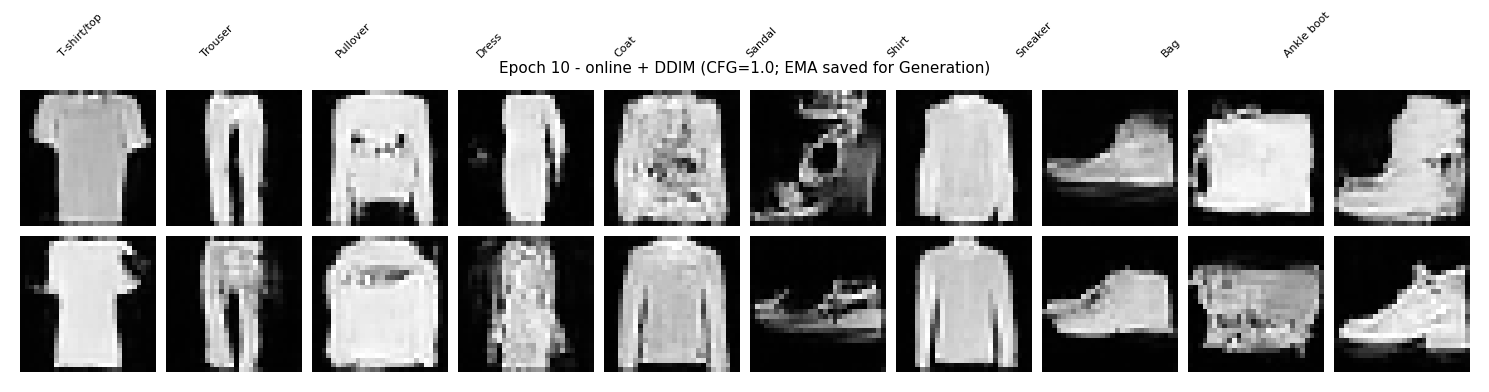

Saved latest: models\conditional_diffusion_improved_final.pt


In [7]:
def show_epoch_samples(model, diffusion, epoch, ddim_steps=100, save_path=None):
    num_classes = NUM_CLASSES
    labels = torch.tensor(list(range(num_classes)) * 2, device=device)
    # Always sample with online weights during training: early EMA can look worse than the live model
    # and confuses epoch-to-epoch monitoring. Checkpoints still save EMA for the Generation cell.
    sample_net = model
    preview_guidance = 1.0
    weight_tag = "online"
    samples = diffusion.sample_ddim(
        sample_net,
        labels.shape[0],
        labels,
        steps=ddim_steps,
        guidance_scale=preview_guidance,
        null_label=NULL_LABEL,
        eta=0.0,
    )
    samples = samples.float() / 255.0
    grid = make_grid(samples, nrow=num_classes, normalize=False, pad_value=1)
    plt.figure(figsize=(15, 4))
    g = grid.permute(1, 2, 0).cpu().numpy()
    if g.ndim == 3 and g.shape[2] == 1:
        plt.imshow(g.squeeze(-1), cmap="gray")
    else:
        plt.imshow(g.squeeze(), cmap="gray")
    plt.title(
        f"Epoch {epoch} - {weight_tag} + DDIM (CFG={preview_guidance}; EMA saved for Generation)",
        fontsize=11,
    )
    plt.axis("off")
    for i in range(num_classes):
        plt.text(i * 28 + 14, -5, class_names[i], ha="center", va="bottom", fontsize=8, rotation=45)
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=220, bbox_inches="tight")
        print(f"Saved final epoch samples: {save_path}")
    plt.show()


def train(
    model,
    dataloader,
    diffusion,
    ema,
    epochs=10,
    lr=1e-3,
    grad_clip=1.0,
    label_dropout_p=0.2,
    ddim_steps=100,
):
    optimizer = Adam(model.parameters(), lr=lr)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=lr * 0.05)
    model.to(device)
    history = {"loss": [], "epoch": []}

    for epoch in range(epochs):
        model.train()
        pbar = tqdm(dataloader, desc=f"Epoch {epoch + 1}/{epochs}")
        loss_avg = 0.0
        for i, (images, labels) in enumerate(pbar):
            images = images.to(device)
            labels = labels.to(device)

            drop = torch.rand(labels.shape[0], device=device) < label_dropout_p
            train_labels = labels.clone()
            train_labels[drop] = NULL_LABEL

            t = diffusion.sample_timesteps(images.shape[0])
            x_t, noise = diffusion.noise_images(images, t)
            pred = model(x_t, t, train_labels)

            per = F.smooth_l1_loss(noise, pred, reduction="none").mean(dim=(1, 2, 3))
            w = diffusion.loss_weight[t]
            loss = (per * w).mean()

            optimizer.zero_grad()
            loss.backward()
            if grad_clip > 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()
            ema.update(model)

            loss_avg += loss.item()
            pbar.set_postfix(Loss=loss_avg / (i + 1))

        epoch_loss = loss_avg / len(dataloader)
        history["loss"].append(epoch_loss)
        history["epoch"].append(epoch + 1)

        if (epoch + 1) == epochs:
            final_samples_path = os.path.join(ASSETS_DIR, "conditional_diffusion_improved_last_epoch_samples.png")
            show_epoch_samples(
                model,
                diffusion,
                epoch + 1,
                ddim_steps=ddim_steps,
                save_path=final_samples_path,
            )
        scheduler.step()

    latest = os.path.join(MODELS_DIR, "conditional_diffusion_improved_final.pt")
    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "ema_shadow_state_dict": ema.shadow.state_dict(),
            "epoch": epochs,
            "img_shape": img_shape,
            "num_timesteps": diffusion.num_timesteps,
            "null_label": NULL_LABEL,
            "min_snr_gamma": diffusion.min_snr_gamma,
            "uniform_loss_weights": diffusion.uniform_loss_weights,
            "label_dropout_p": label_dropout_p,
        },
        latest,
    )
    print(f"Saved latest: {latest}")
    return history


img_shape = (1, 28, 28)
num_timesteps = 1000
diffusion = ImprovedDiffusion(
    num_timesteps,
    img_shape,
    device,
    min_snr_gamma=5.0,
    uniform_loss_weights=True,
)
model = Unet().to(device)
ema = EMA(model, decay=0.998)

train_history = train(
    model,
    dataloader,
    diffusion,
    ema,
    epochs=10,
    grad_clip=1.0,
    label_dropout_p=0.2,
    ddim_steps=100,
)


## Training results

Loss is tracked per epoch. Per-epoch sample grids above help catch collapse or mode issues early.


Saved loss plot: assets\conditional_diffusion_improved_loss.png


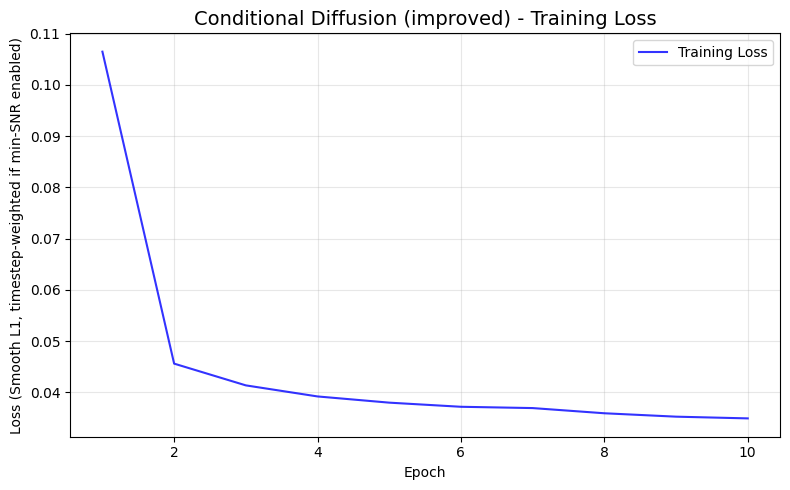

In [8]:
def plot_loss_history(history, save_path=None):
    fig, ax = plt.subplots(1, 1, figsize=(8, 5))
    ax.plot(history["epoch"], history["loss"], color="blue", linestyle="-", alpha=0.8, label="Training Loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss (Smooth L1, timestep-weighted if min-SNR enabled)")
    ax.set_title("Conditional Diffusion (improved) - Training Loss", fontsize=14)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=220, bbox_inches="tight")
        print(f"Saved loss plot: {save_path}")
    plt.show()


loss_plot_path = os.path.join(ASSETS_DIR, "conditional_diffusion_improved_loss.png")
plot_loss_history(train_history, save_path=loss_plot_path)


## Generation

Final samples use **EMA weights**, **DDIM** (100 steps by default), and **CFG**. `guidance_scale=1.0`


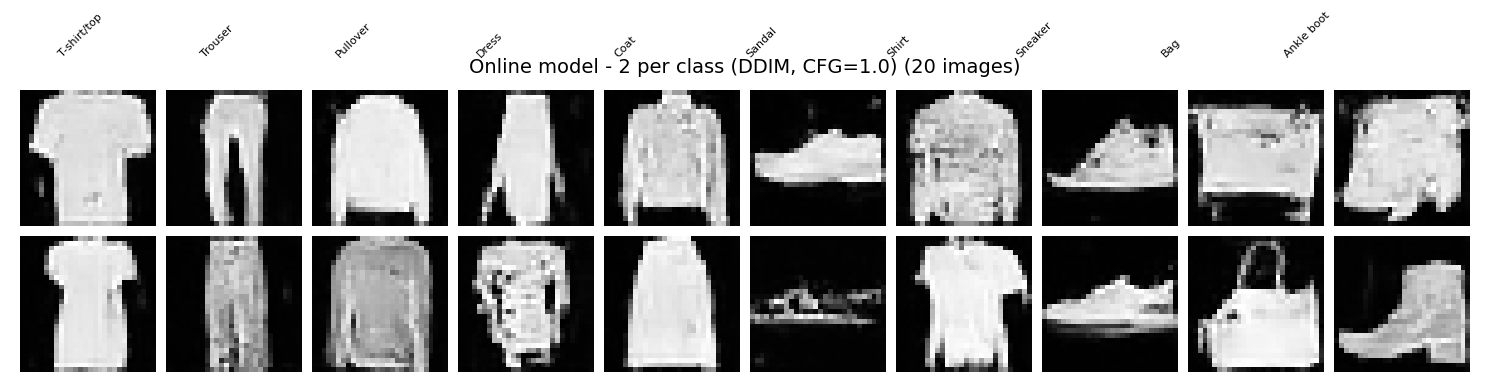

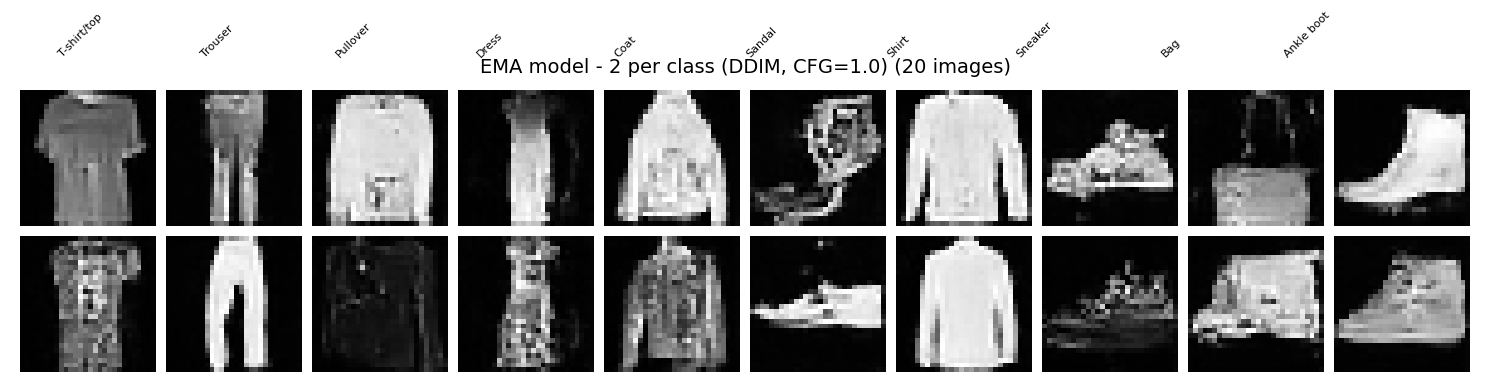

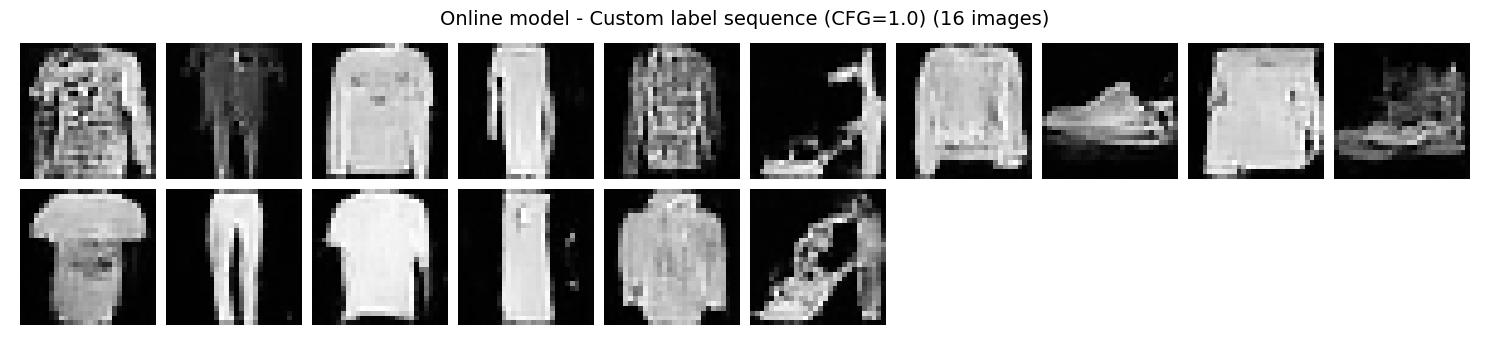

In [9]:
def display_generated_samples(
    sample_model,
    diffusion,
    labels=None,
    title="Conditional Diffusion (improved) - Generated Samples",
    guidance_scale=1.0,
    ddim_steps=100,
):
    num_classes = NUM_CLASSES
    if labels is None:
        labels = torch.tensor(list(range(num_classes)) * 2, device=device)
        num_images = num_classes * 2
    else:
        labels = labels.to(device)
        num_images = len(labels)

    samples = diffusion.sample_ddim(
        sample_model,
        num_images,
        labels,
        steps=ddim_steps,
        guidance_scale=guidance_scale,
        null_label=NULL_LABEL,
        eta=0.0,
    )
    samples = samples.float() / 255.0
    grid = make_grid(samples, nrow=num_classes, normalize=False, pad_value=1)

    plt.figure(figsize=(15, 4))
    grid_np = grid.permute(1, 2, 0).cpu().numpy()
    if grid_np.ndim == 3 and grid_np.shape[2] == 1:
        plt.imshow(grid_np.squeeze(-1), cmap="gray")
    elif grid_np.ndim == 3 and grid_np.shape[2] == 3:
        plt.imshow(grid_np)
    else:
        plt.imshow(grid_np.squeeze(), cmap="gray")
    plt.title(f"{title} ({num_images} images)", fontsize=14)
    plt.axis("off")
    if num_images == num_classes * 2 and labels is not None:
        for i in range(num_classes):
            plt.text(i * 28 + 14, -5, class_names[i], ha="center", va="bottom", fontsize=8, rotation=45)
    plt.tight_layout()
    plt.show()


# Match epoch-preview settings first (online model + CFG=1.0)
display_generated_samples(model, diffusion, title="Online model - 2 per class (DDIM, CFG=1.0)")

# Then compare with EMA using the same safe settings
display_generated_samples(ema.shadow, diffusion, title="EMA model - 2 per class (DDIM, CFG=1.0)")

# Optional custom labels (online model, same settings)
display_generated_samples(
    model,
    diffusion,
    labels=torch.tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 0, 1, 2, 3, 4, 5]).to(device),
    title="Online model - Custom label sequence (CFG=1.0)",
)


## Conditioning debug

Same checks as the baseline notebook: shared noise with different labels vs. different noise with one sample per class. Uses EMA + DDIM + CFG.


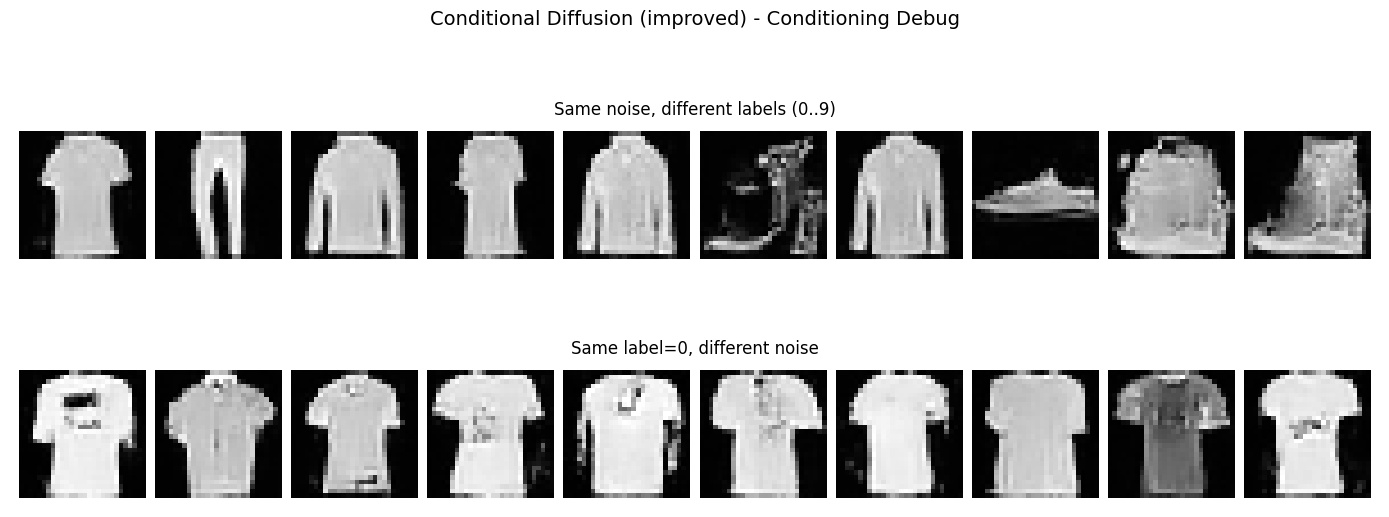

In [10]:
def debug_conditioning(sample_model, diffusion, guidance_scale=1.0, ddim_steps=100):
    sample_model.eval()
    num_classes = NUM_CLASSES
    with torch.no_grad():
        # A) Same noise, different labels (no duplicates)
        labels_a = torch.tensor(list(range(num_classes)), device=device)
        x_seed = torch.randn(1, *diffusion.img_shape, device=device)
        x_shared = x_seed.expand(num_classes, -1, -1, -1).contiguous()
        samples_a = diffusion.sample_ddim(
            sample_model,
            num_classes,
            labels_a,
            steps=ddim_steps,
            guidance_scale=guidance_scale,
            null_label=NULL_LABEL,
            x_start=x_shared,
        )
        grid1 = make_grid(samples_a.float() / 255, nrow=num_classes, normalize=False, pad_value=1)

        # B) Same label, different noise
        fixed_label = 0
        labels_b = torch.full((num_classes,), fixed_label, device=device, dtype=torch.long)
        samples_b = diffusion.sample_ddim(
            sample_model,
            num_classes,
            labels_b,
            steps=ddim_steps,
            guidance_scale=guidance_scale,
            null_label=NULL_LABEL,
        )
        grid2 = make_grid(samples_b.float() / 255, nrow=num_classes, normalize=False, pad_value=1)

    fig, axes = plt.subplots(2, 1, figsize=(14, 6))
    for ax, grid, title in [
        (axes[0], grid1, "Same noise, different labels (0..9)"),
        (axes[1], grid2, f"Same label={fixed_label}, different noise"),
    ]:
        g = grid.permute(1, 2, 0).cpu().numpy()
        if g.shape[2] == 1:
            ax.imshow(g.squeeze(-1), cmap="gray")
        else:
            ax.imshow(g)
        ax.set_title(title, fontsize=12)
        ax.axis("off")
    plt.suptitle("Conditional Diffusion (improved) - Conditioning Debug", fontsize=14)
    plt.tight_layout()
    plt.show()


# Keep debug aligned with training previews
# (online model + CFG=1.0)
debug_conditioning(model, diffusion)
